# Libraries

In [1]:
%run ../setup_workspace.py

✓ Workspace ready


# Data

In [309]:
Exp = BM26_experiment(r"E:/PE Nikos 2025/SC 5732/PE_samples/PE_samples_NG_73_secondheating_140C_and_back")

# Functions

In [310]:
def power(q, I_p, p):
    return I_p * q ** -p 

def Porod(q, I_p):
    return I_p * q ** -4

import numpy as np
from scipy.fft import dct

def linear(q, a, b):
    return a * q + b
    
import numpy as np
from scipy.fft import dct

def cosine_fourier_transform_Iq(q, I_q):
    # Проверка равномерности шага по q
    dq = np.mean(np.diff(q))
    if not np.allclose(np.diff(q), dq, rtol=1e-5):
        raise ValueError("q должен быть равномерно дискретизирован")
    
    # Прямое косинус-преобразование Фурье (DCT-II)
    # Множитель 2/π для соответствия интегральному определению
    F_r = dct(I_q, type=2, norm='ortho') 

    
    
    # r-координаты (обратное пространство)
    N = len(q)
    dr = np.pi / (N * dq)  # шаг по r
    r = np.arange(N) * dr
    
    return r, F_r
def Cosine_FT(q, I, r):
    res = np.zeros(len(r))
    for i in range(len(r)):
        res[i] = np.trapz(I * np.cos(q*r[i]), x=q)
    return res

# Analysis

C:\Users\LabPC\AppData\Local\Temp\ipykernel_7660\423941422.py:14: OptimizeWarning: Covariance of the parameters could not be estimated
  p, cov = curve_fit(power, [q[l], q[r]], [I[l], I[r]], p0=[11, 4])


array([5.34441652, 2.54163538])

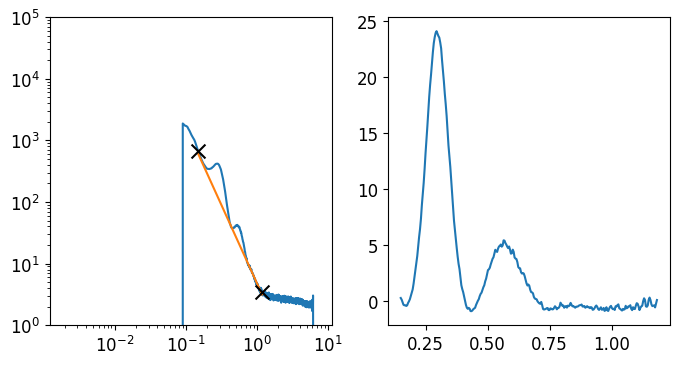

In [315]:
q, I = Exp.get_1d_SAXS()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
    
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.plot(q, I)
#ax1.set_xlim(0.1, 6)
ax1.set_ylim(1, 1e5)

l, r = 40, 320

ax1.scatter([q[l], q[r]], [I[l], I[r]], marker='x', s=100, zorder=10, color='black')
p, cov = curve_fit(power, [q[l], q[r]], [I[l], I[r]], p0=[11, 4])
ax1.plot(q[l:r], 0.9*power(q[l:r], *p))


X = q[l:r]
Y = (I[l:r]-0.98*power(q[l:r], *p))*X**2
ax2.plot(X, Y)
p

C:\Users\LabPC\AppData\Local\Temp\ipykernel_7660\3709240977.py:37: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  res[i] = np.trapz(I * np.cos(q*r[i]), x=q)


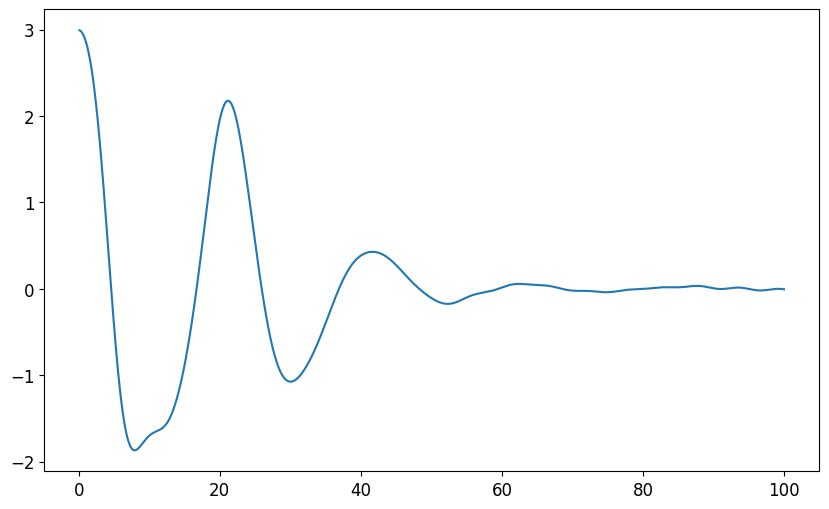

In [316]:
lnsp = np.linspace(0.1, 100, 1000)

plt.plot(lnsp, Cosine_FT(X,  Y, lnsp))
#plt.xlim(0, 20)
